<a href="https://colab.research.google.com/github/BenYILDO/breast_cancer_ML/blob/main/MachineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import plotly.express as px

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, precision_score, accuracy_score, recall_score,
    balanced_accuracy_score, roc_auc_score, confusion_matrix,
    roc_curve
)



------------



# 1. Veri Setinin Yüklenmesi ve İncelenmesi
## 1.1 Veri Seti Yükleme


Öncelikle yüklenen veri setinin hangi bileşenlerden oluştuğunu görmek için `keys( )` fonksiyonu kullanılabilir.




In [ ]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

## 1.2 Veri Çerçevesi Oluşturma

In [ ]:
print("Özellik isimleri:")
print(data.feature_names)

print("\nSınıf isimleri:")
print(data.target_names)

print("\nVeri boyutu:")
print(data.data.shape)

print("\nHedef boyutu:")
print(data.target.shape)

Özellik isimleri:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Sınıf isimleri:
['malignant' 'benign']

Veri boyutu:
(569, 30)

Hedef boyutu:
(569,)


* data.data: bağımsız değişkenleri içerir
* data.target: hedef sınıfı içerir
* data.feature_names: sütun isimlerini verir
* data.target_names: sınıf isimlerini verir
* data.DESCR: veri setinin açıklamasını içerir



Bu çıktı, veri setinin yalnızca gözlem verilerinden oluşmadığını aynı zamanda hedef değişkeni, özellik isimlerini, sınıf isimlerini ve açıklama metnini de içerdiğini göstermektedir.

In [ ]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

In [ ]:
df = pd.concat([X, y], axis=1)

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


- Modelleme aşamasında bağımsız değişkenler `X`, hedef değişken ise `y` olarak ayrılmıştır.
- Keşifsel veri analizi yapabilmek için `X` ve `y` birleştirilerek `df` isimli yeni bir DataFrame oluşturulmuştur.
- Bu sayede özellikler ve hedef sınıf aynı tablo üzerinde birlikte incelenebilir.

In [ ]:
print("X boyutu:", X.shape)
print("y boyutu:", y.shape)
print("df boyutu:", df.shape)

X boyutu: (569, 30)
y boyutu: (569,)
df boyutu: (569, 31)


- Veri setinde 569 gözlem ve 30 bağımsız değişken bulunmaktadır.
- Hedef değişken de eklendiğinde toplam sütun sayısı 31 olmaktadır.
- Bu problem, tümörün iyi huylu veya kötü huylu olmasını tahmin etmeye yönelik iki sınıflı bir sınıflandırma problemidir.








---



# 2. Veri Seti Kalite Kontrolleri

## 2.1 Eksik Değer Analizi

Bu bölümde veri setinde eksik değer olup olmadığı, değişkenlerin veri tipleri ve genel veri yapısı incelenmiştir.
Veri kalitesi kontrolü, modelleme aşamasına geçmeden önce veride hata, eksiklik veya uygunsuz format olup olmadığını anlamak için önemlidir.

In [ ]:
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


Yapılan eksik değer kontrolünde veri setindeki sütunlarda eksik değer bulunmadığı görülmüştür.
Bu nedenle herhangi bir eksik değer doldurma veya silme işlemi uygulanmamıştır.

## 2.2 Aykırı Değer Analizi

Aykırı değer analizi için IQR yöntemi kullanılmıştır.
IQR yöntemi, her değişkenin birinci çeyrek ve üçüncü çeyrek değerleri arasındaki farkı kullanarak olağan dışı gözlemleri belirlemeye yardımcı olur.

In [ ]:
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (X < lower_bound) | (X > upper_bound)

outlier_counts = outlier_mask.sum().sort_values(ascending=False)

outlier_counts

,0
area error,65
radius error,38
perimeter error,38
worst area,35
smoothness error,30
fractal dimension error,28
compactness error,28
symmetry error,27
mean area,25
worst fractal dimension,24


In [ ]:
outlier_table = pd.DataFrame({
    "Aykırı Değer Sayısı": outlier_counts,
    "Aykırı Değer %": outlier_counts / len(X) * 100
})

outlier_table.head(10)

,Aykırı Değer Sayısı,Aykırı Değer %
area error,65,11.423550
radius error,38,6.678383
perimeter error,38,6.678383
worst area,35,6.151142
smoothness error,30,5.272408
fractal dimension error,28,4.920914
compactness error,28,4.920914
symmetry error,27,4.745167
mean area,25,4.393673
worst fractal dimension,24,4.217926


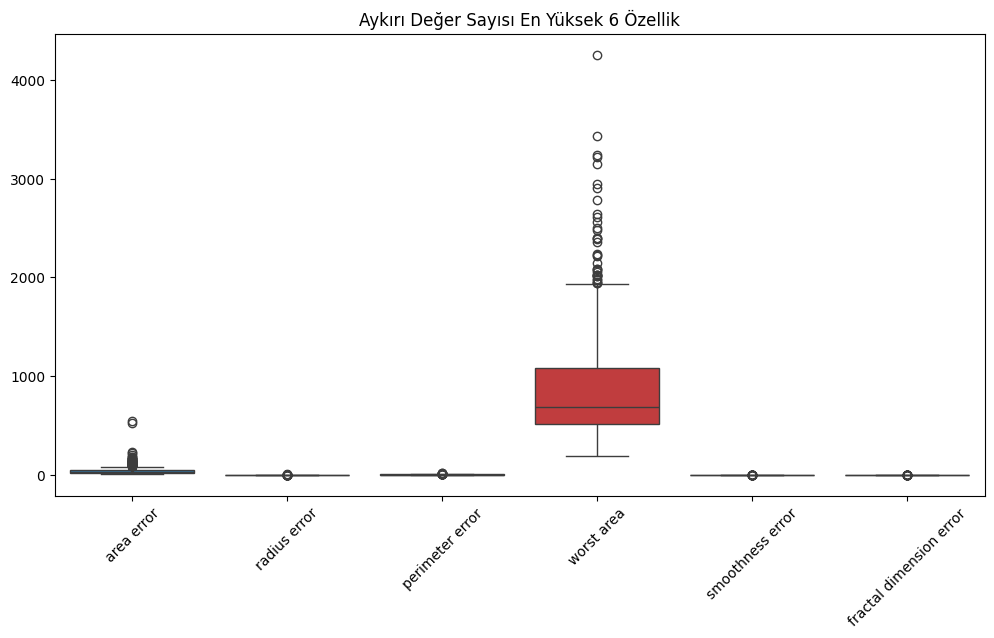

In [ ]:
top_outlier_features = outlier_table.head(6).index

plt.figure(figsize=(12, 6))
sns.boxplot(data=X[top_outlier_features])
plt.xticks(rotation=45)
plt.title("Aykırı Değer Sayısı En Yüksek 6 Özellik")
plt.show()

IQR yöntemi sonucunda bazı özelliklerde aykırı değerler bulunduğu görülmüştür.
Özellikle tümör boyutu, alanı veya çevresiyle ilişkili bazı değişkenlerde değerler geniş bir aralıkta dağılmaktadır.
Bu durum tıbbi veri setlerinde beklenebilir çünkü tümör ölçümleri hastadan hastaya önemli farklılık gösterebilir.

Bu çalışmada aykırı değerler veri setinden çıkarılmamıştır.
Çünkü bu değerler hatalı ölçüm olmak zorunda değildir; gerçek hasta farklılıklarını temsil ediyor olabilir.
Ancak aykırı değerler özellikle Logistic Regression, KNN ve Naive Bayes gibi modellerin performansını etkileyebilir.
Bu nedenle ilerleyen aşamada ölçeklendirme işlemi uygulanacaktır.

## 2.3 Veri Tipi ve Dağılım İncelemesi

Bu bölümde sütunların veri tipleri incelenmiş, sayısal ve kategorik değişken sayıları raporlanmıştır.
Ayrıca hedef değişkenin sınıf dağılımı kontrol edilmiştir.

In [ ]:
df.dtypes

,0
mean radius,float64
mean texture,float64
mean perimeter,float64
mean area,float64
mean smoothness,float64
mean compactness,float64
mean concavity,float64
mean concave points,float64
mean symmetry,float64
mean fractal dimension,float64


In [ ]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = df.select_dtypes(include=["object", "category"]).columns

print("Sayısal değişken sayısı:", len(numeric_columns))
print("Kategorik değişken sayısı:", len(categorical_columns))

Sayısal değişken sayısı: 31
Kategorik değişken sayısı: 0


Veri setindeki tüm değişkenlerin sayısal veri tipinde olduğu görülmektedir.
Bu nedenle kategorik değişkenler için encoding işlemi yapılmasına gerek yoktur.
`target` değişkeni sayısal görünmesine rağmen sınıf bilgisini temsil etmektedir.



---



# 3. Keşifsel Veri Analizi (EDA)

## 3.1 İstatistiksel Özellikler

Bu bölümde veri setindeki bağımsız değişkenlerin temel istatistiksel özellikleri incelenmiştir.
Her özellik için ortalama, medyan, minimum, maksimum, standart sapma, birinci çeyrek ve üçüncü çeyrek değerleri hesaplanmıştır.

In [ ]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


`describe()` fonksiyonu ile her özellik için temel istatistiksel değerler incelenmiştir.
Tablodaki `mean` ortalamayı, `std` standart sapmayı, `min` ve `max` minimum-maksimum değerleri, `25%` Q1 değerini, `50%` medyanı ve `75%` Q3 değerini göstermektedir.

Eğer 'Mean', 'Median', 'Min', 'Q1', 'Q3', 'Max', 'Std' şeklinde tablo istemi zorunlu ise aşağıdaki gibi tabloyu inceleyebiliriz.

In [ ]:
stats = X.describe().T[['mean', '50%', 'min', 'max', 'std']]
stats.columns = ['Mean', 'Median', 'Min', 'Max', 'Std']
stats['Q1'] = X.quantile(0.25)
stats['Q3'] = X.quantile(0.75)
pd.set_option('display.float_format', '{:.3f}'.format)
display(stats)

,Mean,Median,Min,Max,Std,Q1,Q3
mean radius,14.127,13.370,6.981,28.110,3.524,11.700,15.780
mean texture,19.290,18.840,9.710,39.280,4.301,16.170,21.800
mean perimeter,91.969,86.240,43.790,188.500,24.299,75.170,104.100
mean area,654.889,551.100,143.500,2501.000,351.914,420.300,782.700
mean smoothness,0.096,0.096,0.053,0.163,0.014,0.086,0.105
mean compactness,0.104,0.093,0.019,0.345,0.053,0.065,0.130
mean concavity,0.089,0.062,0.000,0.427,0.080,0.030,0.131
mean concave points,0.049,0.034,0.000,0.201,0.039,0.020,0.074
mean symmetry,0.181,0.179,0.106,0.304,0.027,0.162,0.196
mean fractal dimension,0.063,0.062,0.050,0.097,0.007,0.058,0.066


## 3.2 Korelasyon Matrisi

Bu bölümde özellikler arasındaki doğrusal ilişkileri incelemek için Pearson korelasyon matrisi oluşturulmuştur.
Korelasyon değeri:
* 1’e yaklaştıkça pozitif yönlü güçlü ilişki
* -1’e yaklaştıkça negatif yönlü güçlü ilişki
olduğunu gösterir.

In [ ]:
correlation_matrix = X.corr(method="pearson")

correlation_matrix

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
mean radius,1.000,0.324,0.998,0.987,0.171,0.506,0.677,0.823,0.148,-0.312,...,0.970,0.297,0.965,0.941,0.120,0.413,0.527,0.744,0.164,0.007
mean texture,0.324,1.000,0.330,0.321,-0.023,0.237,0.302,0.293,0.071,-0.076,...,0.353,0.912,0.358,0.344,0.078,0.278,0.301,0.295,0.105,0.119
mean perimeter,0.998,0.330,1.000,0.987,0.207,0.557,0.716,0.851,0.183,-0.261,...,0.969,0.303,0.970,0.942,0.151,0.456,0.564,0.771,0.189,0.051
mean area,0.987,0.321,0.987,1.000,0.177,0.499,0.686,0.823,0.151,-0.283,...,0.963,0.287,0.959,0.959,0.124,0.390,0.513,0.722,0.144,0.004
mean smoothness,0.171,-0.023,0.207,0.177,1.000,0.659,0.522,0.554,0.558,0.585,...,0.213,0.036,0.239,0.207,0.805,0.472,0.435,0.503,0.394,0.499
mean compactness,0.506,0.237,0.557,0.499,0.659,1.000,0.883,0.831,0.603,0.565,...,0.535,0.248,0.590,0.510,0.566,0.866,0.816,0.816,0.510,0.687
mean concavity,0.677,0.302,0.716,0.686,0.522,0.883,1.000,0.921,0.501,0.337,...,0.688,0.300,0.730,0.676,0.449,0.755,0.884,0.861,0.409,0.515
mean concave points,0.823,0.293,0.851,0.823,0.554,0.831,0.921,1.000,0.462,0.167,...,0.830,0.293,0.856,0.810,0.453,0.667,0.752,0.910,0.376,0.369
mean symmetry,0.148,0.071,0.183,0.151,0.558,0.603,0.501,0.462,1.000,0.480,...,0.186,0.091,0.219,0.177,0.427,0.473,0.434,0.430,0.700,0.438
mean fractal dimension,-0.312,-0.076,-0.261,-0.283,0.585,0.565,0.337,0.167,0.480,1.000,...,-0.254,-0.051,-0.205,-0.232,0.505,0.459,0.346,0.175,0.334,0.767


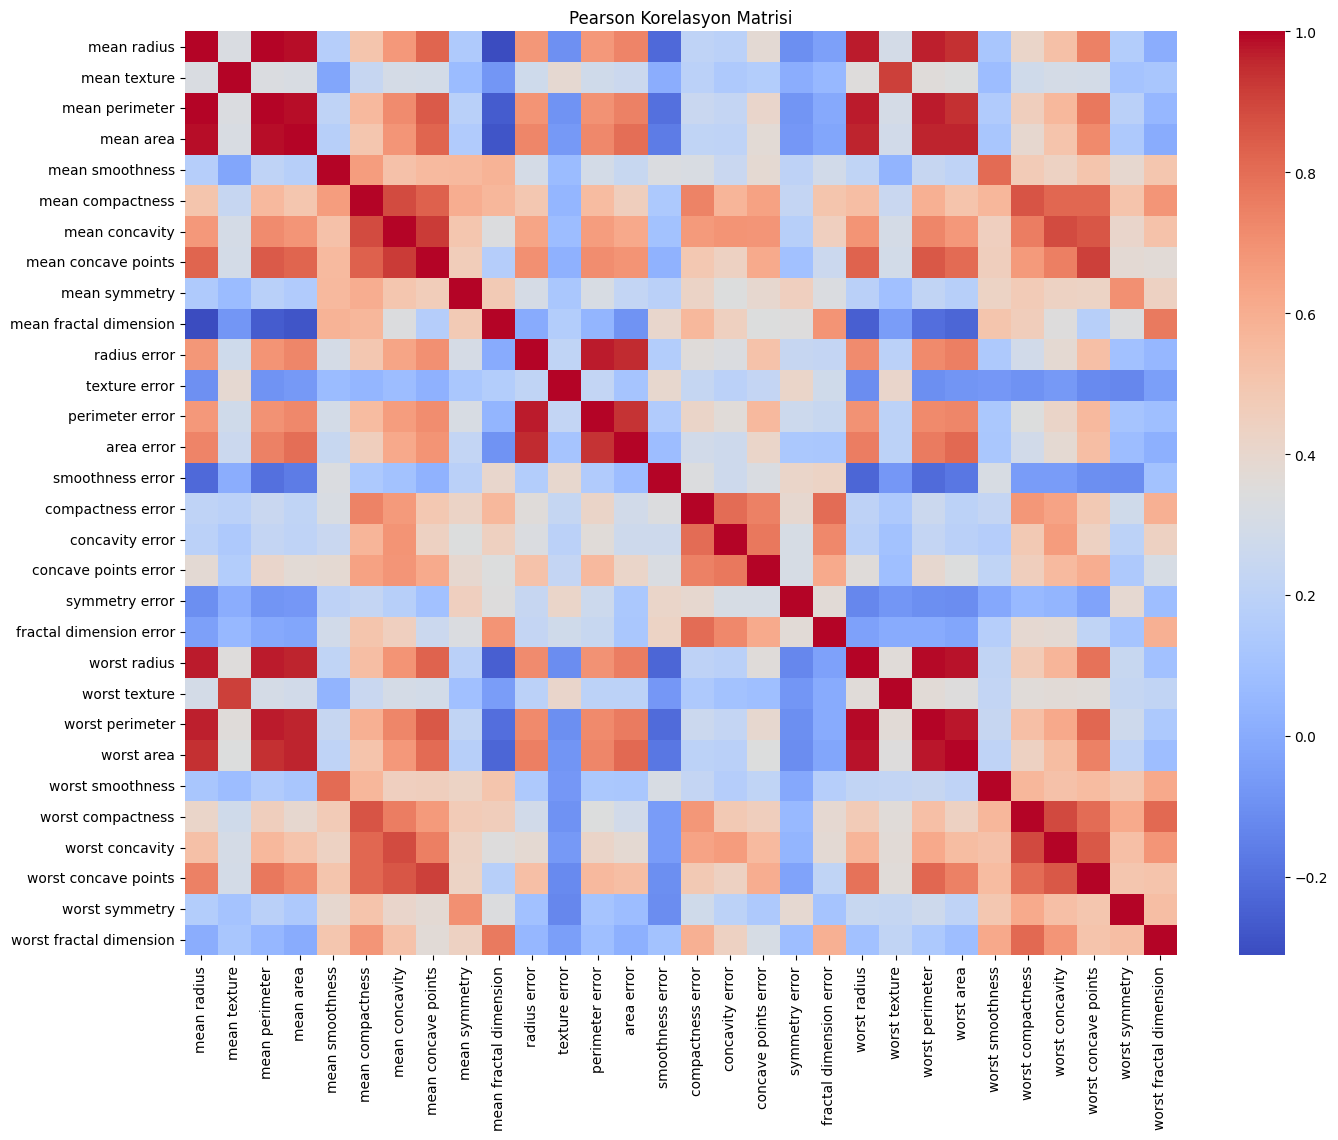

In [ ]:
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, cmap="coolwarm")
plt.title("Pearson Korelasyon Matrisi")
plt.show()

In [ ]:
corr_pairs = correlation_matrix.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]

corr_pairs.head(6)

,,0
mean perimeter,mean radius,0.998
mean radius,mean perimeter,0.998
worst radius,worst perimeter,0.994
worst perimeter,worst radius,0.994
mean radius,mean area,0.987
mean area,mean radius,0.987


En yüksek korelasyonlu özellik çiftleri incelendiğinde tümörün yarıçap, çevre ve alan ölçümleriyle ilişkili değişkenlerin birbirleriyle güçlü pozitif ilişkiye sahip olduğu görülmektedir.
Bu beklenen bir durumdur çünkü yarıçap arttıkça tümörün çevresi ve alanı da artmaktadır.

## 3.3 Boxplot Analizi

Bu bölümde her özellik için boxplot grafikleri çizilmiştir.
Özellikler veri setindeki yapıya uygun olarak üç gruba ayrılmıştır: mean özellikler, error özellikleri ve worst özellikler.
Her boxplot grafiğinde malignant ve benign sınıfları ayrı ayrı gösterilmiştir.

In [ ]:
# Özellikleri 3 gruba ayırıyoruz
feature_groups = [
    data.feature_names[:10],
    data.feature_names[10:20],
    data.feature_names[20:]
]

group_names = [
    "Mean Özellikler",
    "Error Özellikleri",
    "Worst Özellikler"
]

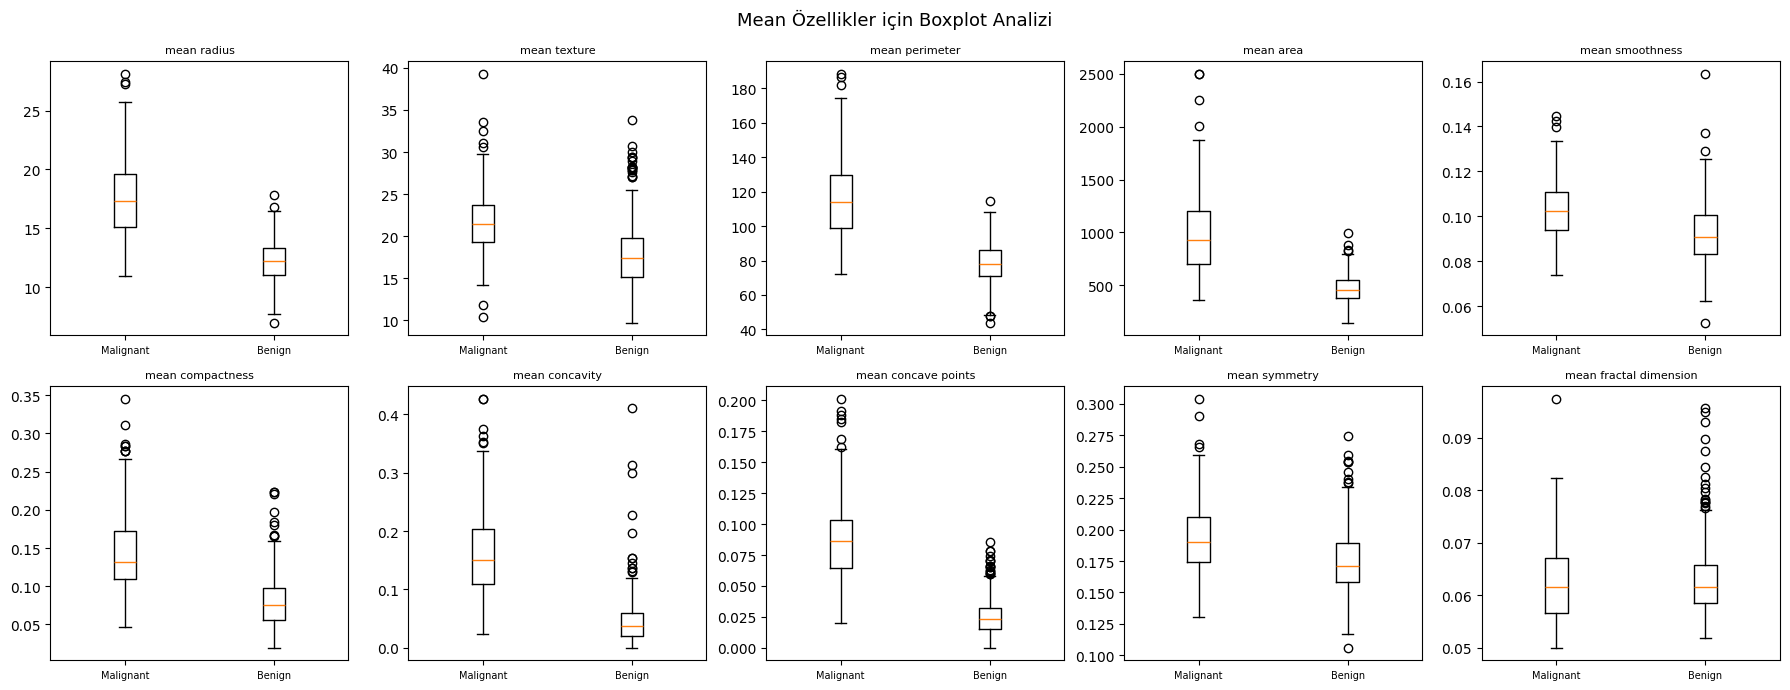

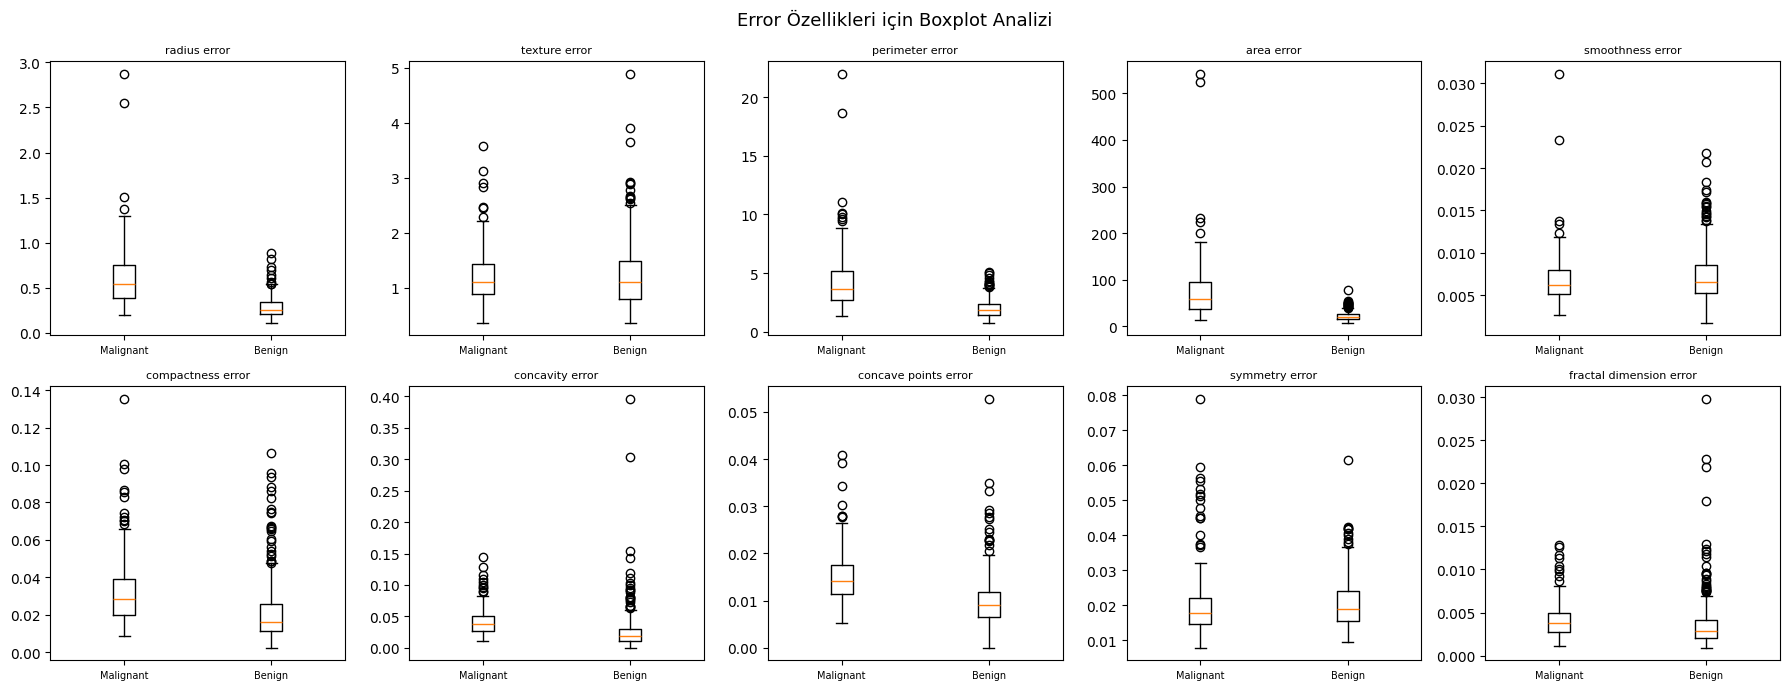

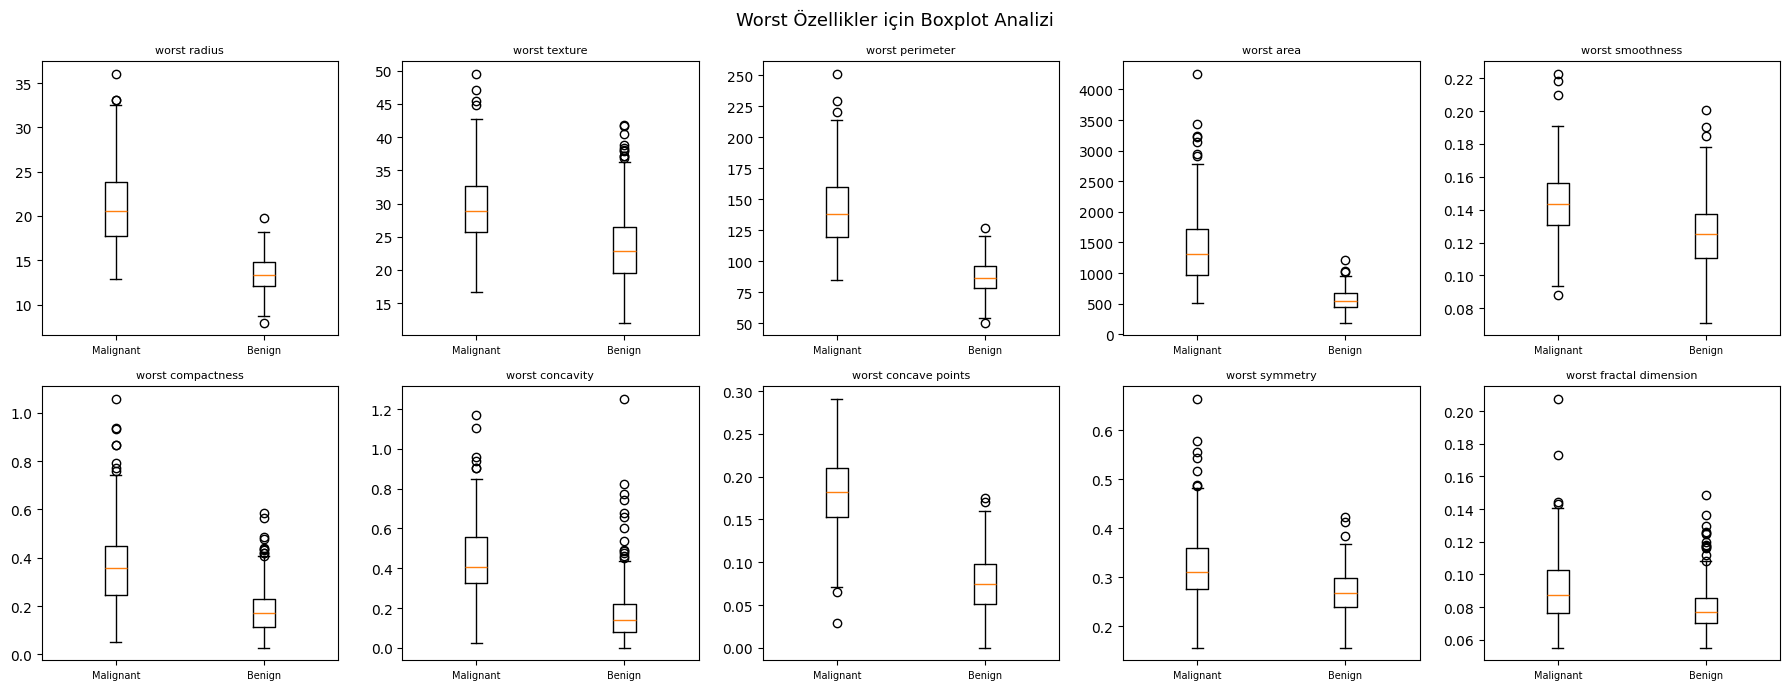

In [ ]:
# Her grup için sınıflara göre boxplot çiziyoruz
for features, group_name in zip(feature_groups, group_names):
    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    axes = axes.flatten()

    for i, feature in enumerate(features):
        axes[i].boxplot([
            X[feature][y == 0],
            X[feature][y == 1]
        ])

        axes[i].set_title(feature, fontsize=8)
        axes[i].set_xticklabels(["Malignant", "Benign"], fontsize=7)

    fig.suptitle(f"{group_name} için Boxplot Analizi", fontsize=13)
    plt.tight_layout()
    plt.show()

Boxplot grafikleri incelendiğinde bazı özelliklerde malignant ve benign sınıfları arasında belirgin farklılıklar olduğu görülmektedir.
Özellikle radius, perimeter, area ve concave points gibi tümör boyutu ve şekliyle ilişkili özelliklerde malignant sınıfının değerleri genellikle daha yüksektir.
Bu durum, bu değişkenlerin sınıflandırma modelleri için ayırt edici bilgi taşıyabileceğini göstermektedir.

Ayrıca bazı özelliklerde kutu dışında kalan noktalar aykırı değer eğilimini göstermektedir.
Bu aykırı değerler tıbbi ölçümlerde gerçek hasta farklılıklarından kaynaklanabileceği için bu aşamada veri setinden çıkarılmamıştır.



---



# 4. Veri Setinin Bölünmesi

* Bu bölümde veri seti eğitim, validation ve test setlerine ayrılmıştır.
* Veri seti %70 training, %10 validation ve %20 test olacak şekilde bölünmüştür.
* Validation seti, modelleri karşılaştırmak ve en iyi modeli seçmek için kullanılacaktır.
* Test seti ise en son aşamada seçilen modelin gerçek performansını değerlendirmek için ayrılmıştır.

In [ ]:
# %80 train+validation / %20 test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
# Kalan %80'i %70 train / %10 validation olarak bölüyoruz
# %10 / %80 = 0.125
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.125,
    random_state=42,
    stratify=y_temp
)


In [ ]:
print("Veri seti bölünme sonuçları:")
print(f"Toplam  : {len(X):4d} örnek")
print(f"Train   : {len(X_train):4d} örnek  (%{len(X_train)/len(X)*100:.1f})")
print(f"Val     : {len(X_val):4d} örnek  (%{len(X_val)/len(X)*100:.1f})")
print(f"Test    : {len(X_test):4d} örnek  (%{len(X_test)/len(X)*100:.1f})")

Veri seti bölünme sonuçları:
Toplam  :  569 örnek
Train   :  398 örnek  (%69.9)
Val     :   57 örnek  (%10.0)
Test    :  114 örnek  (%20.0)


In [ ]:
print("\nSınıf dağılımları:")
for name, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    counts = pd.Series(y_split).value_counts().sort_index()
    print(f"{name}: malignant={counts[0]}, benign={counts[1]}")


Sınıf dağılımları:
Train: malignant=149, benign=249
Val: malignant=21, benign=36
Test: malignant=42, benign=72


Veri seti önce %80 train-validation ve %20 test olarak ayrılmıştır.
Daha sonra %80'lik geçici veri seti kendi içinde train ve validation olarak bölünmüştür.
Böylece yaklaşık olarak %70 train, %10 validation ve %20 test oranları elde edilmiştir.

`stratify=y` kullanılarak malignant ve benign sınıflarının train, validation ve test setlerinde benzer oranlarda dağılması sağlanmıştır.



---



# 5. Veri Ölçeklendirme (Scaling)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

In [ ]:
X_scaled = pd.concat([X_train_scaled, X_val_scaled, X_test_scaled], axis=0)

X_scaled.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
301,-0.465,0.177,-0.468,-0.519,-0.884,-0.073,-0.281,-0.467,-0.077,-0.069,...,-0.573,-0.379,-0.561,-0.578,-1.226,-0.259,-0.416,-0.585,-0.340,-0.358
390,-1.084,-1.553,-1.065,-0.944,0.251,-0.554,-0.869,-0.753,-0.010,0.375,...,-1.001,-1.547,-1.000,-0.855,0.070,-0.573,-0.893,-0.724,0.046,-0.381
420,-0.715,-0.015,-0.721,-0.694,-0.814,-0.521,-0.442,-0.889,0.806,-0.044,...,-0.654,0.237,-0.611,-0.633,-0.346,-0.396,-0.117,-0.728,0.196,-0.074
356,-0.299,-0.116,-0.278,-0.403,0.855,0.463,0.052,0.166,0.821,0.281,...,-0.423,-0.099,-0.382,-0.508,0.070,0.049,-0.111,0.155,0.315,-0.055
446,1.024,2.013,1.034,0.933,0.251,0.482,0.936,0.846,-0.317,-0.532,...,1.086,2.057,1.128,0.984,0.327,0.731,1.638,1.218,0.100,0.359
